# Graph Analytics su COVID-19 — Manuel Testoni (219155)

## Analysis Context
We discussed many times of how virusses were a good case study for data represented as graph.
Covid 19 has affected all countries in the world, giving a good starting point for analysis for the deepening of this part of the course.
My aim in this notebook is to study how and if countries are grouped by pandemic profile
(information such as: epidemiological outcomes, policy response, social and health context) and 
**which ate the most representative/central countries** in the graph.

## Dataset
The data I use comes from the **COVID-19 Open Data** repository, a large open dataset built and maintained by Google (Google Cloud / Google Health) during the pandemic. It is one of the most complete COVID resources around, because it does not contain only case counts: it joins together many different sources (epidemiology, vaccinations, the Oxford government response tracker, Google mobility reports, demographics, economy and health indicators) into a single structure.

Every row is identified by a `location_key` and an `aggregation_level`, that tells us if a record refers to a country, a region or a smaller administrative area. The dataset is spatially very granular: it covers more than 20,000 locations in the world, with hundreds of variables organised as daily time series. For my analysis I keep only `aggregation_level = 0`, that means the **country level**, and I aggregate the time series into one summary row per country.

- **Source:** Google COVID-19 Open Data — https://github.com/GoogleCloudPlatform/covid-19-open-data
- **Files used:** `index.csv`, `epidemiology.csv`, `vaccinations.csv`, `oxford-government-response.csv`, `mobility.csv`, `demographics.csv`, `economy.csv`, `health.csv`.
- **Size:** global coverage (20,000+ locations), several CSV files with millions of rows each, this is the reason why I read them in chunks during preprocessing.
- **Citation:** Wahltinez, O. et al. (2023). *COVID-19 Open-Data: a global-scale spatially granular meta-dataset for coronavirus disease.* Scientific Data, 10, 84.

## Graph Schema
| Element | Description |
|----------|-------------|
| `(:Country)` | A country (`aggregation_level = 0`). Properties: epidemiological outocmes, vaccination coverage, peak of policy rigour, drop in mobility, social, health and economic indicators, plus the standardised 'features' vector. |
| `(:Continent)` | A continent (Europe, Asia, Africa, North/South America, Oceania). |
| `(:Country)-[:IN_CONTINENT]->(:Continent)` | Geographical Ownership (derived by ISO code). |
| `(:Country)-[:SIMILAR {score}]->(:Country)` | Similarity built using **GDS KNN** on `features` vector. |

## Research question
- **RQ1 — Community:** *Which countries form communities with a similar pandemic profile?* → KNN (arch construction) + **Louvain**, **native** projection.
- **RQ2 — Centralità:** *Which countries are the most central/representative in the similarity network?* → **PageRank** + **Betweenness**, **Cypher** projection.

## 1. Setup — Library and Connections

Requirement needed are listed in the file: `requirements.txt` which are:

`neo4j`, `graphdatascience`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `networkx`, `pycountry-convert`.

> **Local Neo4j Instance**: I've used a local neo4j instance running on my machine. The instance must be running with APOC and GDS plugins installed.

In [61]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from neo4j import GraphDatabase
from graphdatascience import GraphDataScience
import pycountry_convert as pcc

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

# I will use this path later to load data files.
RAW = Path("raw")
assert RAW.exists(), f"Directory {RAW.resolve()} Not found"

In [ ]:
NEO4J_URI      = "neo4j://127.0.0.1:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = #I've removed password for the delivery of this assignment
NEO4J_DATABASE = "covid-19"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

def run_query(cypher, params=None):
    """Esegue una query Cypher e restituisce un DataFrame."""
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(cypher, params or {})
        return pd.DataFrame([r.data() for r in result])

def run_scalar(cypher, params=None):
    df = run_query(cypher, params)
    return df.iloc[0, 0] if not df.empty else None

gds = GraphDataScience(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD), database=NEO4J_DATABASE)

driver.verify_connectivity()
print("Connected successfully")

Connected successfully


## 1.5 Indexes — accelerate cypher queries


I've studied that Neo4j supports a huge amount of indexes and i must take advantage of this. if not, every time we use a WHERE clause, we implicitely dare the execution planner to scan all the nodes to find the excact match.


| Index | Entity | Property | Used to |
|--------|--------|-----------|---------|
| `country_community` | node `:Country` | `community` | filter communities per Louvain |
| `similar_score` | relation `:SIMILAR` | `score` | filter on strong edges, the one that exceed over a threshold |

Uniqueness constraints are already satisfied and applied on `Country.location_key` and `Continent.name`.

I will verify in the next sections wether the indexes i've built here are actually used or not.

In [ ]:
run_query("CREATE INDEX country_community IF NOT EXISTS "
          "FOR (c:Country) ON (c.community)")     # Used in: WHERE c.community = $cid  (RQ1)
run_query("CREATE INDEX similar_score IF NOT EXISTS "
          "FOR ()-[r:SIMILAR]-() ON (r.score)")   # Used in: WHERE r.score >= threshold  (RQ2)


#   profile=False → EXPLAIN: only the estimated plan
#   profile=True  → PROFILE: execute and shows the plan
def show_plan(cypher, params=None, profile=False):
    kw = "PROFILE" if profile else "EXPLAIN"
    with driver.session(database=NEO4J_DATABASE) as session:
        summary = session.run(f"{kw} {cypher}", params or {}).consume()
        plan = summary.profile if profile else summary.plan
    def walk(p, depth=0):
        op  = p.get("operatorType", "?")
        det = p.get("args", {}).get("Details", "")
        rows = f"   [{p['args']['Rows']} rows]" if profile and "Rows" in p.get("args", {}) else ""
        print("    " * depth + f"• {op}" + (f"  —  {det}" if det else "") + rows)
        for ch in p.get("children", []):
            walk(ch, depth + 1)
    walk(plan)

display(run_query(
    "SHOW INDEXES YIELD name, type, entityType, labelsOrTypes, properties, state "
    "RETURN name, type, entityType, labelsOrTypes, properties, state ORDER BY name"))

,name,type,entityType,labelsOrTypes,properties,state
0,continent_name,RANGE,NODE,[Continent],[name],ONLINE
1,country_community,RANGE,NODE,[Country],[community],ONLINE
2,country_key,RANGE,NODE,[Country],[location_key],ONLINE
3,index_1b9dcc97,LOOKUP,RELATIONSHIP,None,None,ONLINE
4,index_460996c0,LOOKUP,NODE,None,None,ONLINE
5,similar_score,RANGE,RELATIONSHIP,[SIMILAR],[score],ONLINE


## 2. Preprocessing — from CSV to tables

Since original CSV were huge I had to create these tables:

1. Selecting **only countries** (`aggregation_level = 0`) from `index.csv`.
2. Importing (`epidemiology`, `vaccinations`, `oxford`, `mobility`) and **aggregating them per country**.
3. Unifying static tables (`demographics`, `economy`, `health`).

In [ ]:
idx = pd.read_csv(RAW/"index.csv", dtype=str)
idx = idx[idx["aggregation_level"] == "0"].copy()
country_keys = set(idx["location_key"])
print(f"Weights (level 0): {len(country_keys)}")

countries = idx[["location_key", "country_name",
                 "iso_3166_1_alpha_2", "iso_3166_1_alpha_3"]].rename(
    columns={"country_name": "name",
             "iso_3166_1_alpha_2": "iso2",
             "iso_3166_1_alpha_3": "iso3"}).set_index("location_key")
countries.head()

Weights (level 0): 246


,name,iso2,iso3
location_key,,,
AD,Andorra,AD,AND
AE,United Arab Emirates,AE,ARE
AF,Afghanistan,AF,AFG
AG,Antigua and Barbuda,AG,ATG
AI,Anguilla,AI,AIA


In [ ]:
#Using chunk to aggregate data by country without loading everything in memory.
CHUNK = 1_000_000

def chunk_groupby_max(path, value_cols, key="location_key"):
    """Maximum per country (on chunk since I'm reading ona at time)."""
    acc = None
    for ch in pd.read_csv(path, usecols=[key]+value_cols, chunksize=CHUNK):
        ch = ch[ch[key].isin(country_keys)]
        if ch.empty:
            continue
        g = ch.groupby(key)[value_cols].max()
        acc = g if acc is None else pd.concat([acc, g]).groupby(level=0).max()
    return acc if acc is not None else pd.DataFrame(columns=value_cols)

def chunk_groupby_mean(path, value_cols, key="location_key"):
    """Mean per country (on chunk)."""
    s = None; c = None
    for ch in pd.read_csv(path, usecols=[key]+value_cols, chunksize=CHUNK):
        ch = ch[ch[key].isin(country_keys)]
        if ch.empty:
            continue
        gs = ch.groupby(key)[value_cols].sum()
        gc = ch.groupby(key)[value_cols].count()
        s = gs if s is None else pd.concat([s, gs]).groupby(level=0).sum()
        c = gc if c is None else pd.concat([c, gc]).groupby(level=0).sum()
    if s is None:
        return pd.DataFrame(columns=value_cols)
    return s / c.replace(0, np.nan)

In [ ]:
#Epidemiology total (infections, deaths)
epi = chunk_groupby_max(RAW/"epidemiology.csv",
                        ["cumulative_confirmed", "cumulative_deceased"])
print("aggregate epidemiology:", epi.shape); epi.head()

aggregate epidemiology: (232, 2)


,cumulative_confirmed,cumulative_deceased
location_key,,
AD,46147.0,155.0
AE,1021191.0,2342.0
AF,196663.0,7791.0
AG,9008.0,145.0
AI,3856.0,12.0


In [ ]:
#Vaccination: people fully vaccinated
vax = chunk_groupby_max(RAW/"vaccinations.csv",
                        ["cumulative_persons_fully_vaccinated"])
print("aggregate vaccinations:", vax.shape); vax.head()

aggregate vaccinations: (218, 1)


,cumulative_persons_fully_vaccinated
location_key,
AD,53478.0
AE,9792266.0
AF,10105500.0
AG,62031.0
AI,10314.0


In [ ]:
#Oxford policies
oxf_raw = pd.read_csv(RAW/"oxford-government-response.csv",
                      usecols=["location_key", "stringency_index"])
oxf_raw = oxf_raw[oxf_raw["location_key"].isin(country_keys)]
oxf = oxf_raw.groupby("location_key")["stringency_index"].agg(
    peak_stringency="max", mean_stringency="mean")
print("oxford aggregate:", oxf.shape); oxf.head()

oxford aggregate: (186, 2)


,peak_stringency,mean_stringency
location_key,,
AD,65.74,40.313651
AE,89.81,49.538935
AF,84.26,30.769232
AL,89.81,48.896938
AO,90.74,56.860295


In [ ]:
#Mobility: workplaces and retail/recreation
mob = chunk_groupby_mean(RAW/"mobility.csv",
                         ["mobility_workplaces", "mobility_retail_and_recreation"])
mob = mob.rename(columns={"mobility_workplaces": "mean_mobility_workplaces",
                          "mobility_retail_and_recreation": "mean_mobility_retail"})
print("mobility aggregate:", mob.shape); mob.head()

mobility aggregate: (128, 2)


,mean_mobility_workplaces,mean_mobility_retail
location_key,,
AE,-6.257173,-6.553666
AF,-0.136161,43.005741
AG,-22.172193,4.028384
AO,7.514346,28.794899
AR,-1.825717,-26.130712


In [ ]:
#Demographics and health: population, density, HDI, life expectancy, hospital beds, diabetes and smoking prevalence
demo = pd.read_csv(RAW/"demographics.csv",
        usecols=["location_key", "population", "population_density",
                 "human_development_index"]).set_index("location_key")
econ = pd.read_csv(RAW/"economy.csv",
        usecols=["location_key", "gdp_per_capita_usd"]).set_index("location_key")
health = pd.read_csv(RAW/"health.csv",
        usecols=["location_key", "life_expectancy", "hospital_beds_per_1000",
                 "diabetes_prevalence", "smoking_prevalence"]).set_index("location_key")
print("demo", demo.shape, "| econ", econ.shape, "| health", health.shape)

demo (21689, 3) | econ (404, 1) | health (3504, 4)


In [ ]:
#Derivate features and join everything in a single table (one row per country).
df = (countries
      .join(demo, how="left").join(econ, how="left").join(health, how="left")
      .join(epi, how="left").join(vax, how="left")
      .join(oxf, how="left").join(mob, how="left"))

pop = df["population"].astype(float).replace(0, np.nan)
df["total_confirmed_per100k"] = df["cumulative_confirmed"] / pop * 1e5
df["total_deceased_per100k"]  = df["cumulative_deceased"]  / pop * 1e5
df["cfr"] = df["cumulative_deceased"] / df["cumulative_confirmed"].replace(0, np.nan) * 100
df["pct_fully_vaccinated"] = df["cumulative_persons_fully_vaccinated"] / pop * 100

def to_continent(iso2):
    try:
        return pcc.convert_continent_code_to_continent_name(
            pcc.country_alpha2_to_continent_code(iso2))
    except Exception:
        return None
df["continent"] = df["iso2"].apply(lambda x: to_continent(x) if isinstance(x, str) else None)

print("Country Table:", df.shape)
df[["name", "continent", "total_confirmed_per100k", "total_deceased_per100k",
    "cfr", "pct_fully_vaccinated", "peak_stringency"]].head(10)

Country Table: (246, 23)


,name,continent,total_confirmed_per100k,total_deceased_per100k,cfr,pct_fully_vaccinated,peak_stringency
location_key,,,,,,,
AD,Andorra,Europe,59725.619621,200.608296,0.335883,69.213745,65.74
AE,United Arab Emirates,Asia,10325.072798,23.679528,0.229340,99.007785,89.81
AF,Afghanistan,Asia,505.192348,20.013696,3.961599,25.959236,84.26
AG,Antigua and Barbuda,North America,9198.594886,148.067968,1.609680,63.343477,NaN
AI,Anguilla,North America,25703.239568,79.989335,0.311203,68.750833,NaN
AL,Albania,Europe,11533.883659,125.278304,1.086176,44.062015,89.81
AM,Armenia,Asia,14825.086375,292.551989,1.973358,33.267943,NaN
AN,Netherlands Antilles,None,NaN,NaN,NaN,NaN,NaN
AO,Angola,Africa,313.789820,5.832728,1.858801,23.775505,90.74


In [ ]:
#Before loading the graph, I will create a "features" column with all the 
# relevant features normalized and ready to be used in the similarity calculation (RQ2).
FEATURE_COLS = [
    "total_confirmed_per100k", "total_deceased_per100k", "cfr",
    "pct_fully_vaccinated", "peak_stringency", "mean_stringency",
    "mean_mobility_workplaces", "mean_mobility_retail",
    "population_density", "human_development_index", "gdp_per_capita_usd",
    "life_expectancy", "hospital_beds_per_1000", "diabetes_prevalence",
]
feat = df[FEATURE_COLS].astype(float)
feat = feat.fillna(feat.median())
feat_z = (feat - feat.mean()) / feat.std(ddof=0)
df["features"] = feat_z.round(4).values.tolist()

df_load = df[df["cumulative_confirmed"].notna()].copy()
print(f"Country to look for: {len(df_load)}")
df_load[["name", "continent"]].head()

Country to look for: 231


,name,continent
location_key,,
AD,Andorra,Europe
AE,United Arab Emirates,Asia
AF,Afghanistan,Asia
AG,Antigua and Barbuda,North America
AI,Anguilla,North America


## 3. Graph population

Let's build the nodes `(:Country)`/`(:Continent)` and edges `IN_CONTINENT` with `MERGE`
passing batch data using `UNWIND $rows`. `features` vector is saved as a list of properties, ready for KNN.

In [ ]:
# Uniqueness constraints + graph reset
run_query("MATCH (n) DETACH DELETE n")
run_query("CREATE CONSTRAINT country_key IF NOT EXISTS "
          "FOR (c:Country) REQUIRE c.location_key IS UNIQUE")
run_query("CREATE CONSTRAINT continent_name IF NOT EXISTS "
          "FOR (k:Continent) REQUIRE k.name IS UNIQUE")
print("Graph resetted, constraints created.")

Graph resetted, constraints created.


In [ ]:
#Loading country node + IN_CONTINENT edges
NUM_PROPS = ["population", "population_density", "human_development_index",
             "gdp_per_capita_usd", "life_expectancy", "hospital_beds_per_1000",
             "diabetes_prevalence", "smoking_prevalence",
             "total_confirmed_per100k", "total_deceased_per100k", "cfr",
             "pct_fully_vaccinated", "peak_stringency", "mean_stringency",
             "mean_mobility_workplaces", "mean_mobility_retail"]

rows = []
for key, r in df_load.iterrows():
    rec = {"key": key, "name": r["name"], "iso3": r["iso3"],
           "continent": r["continent"], "features": r["features"]}
    for c in NUM_PROPS:
        v = r[c]
        rec[c] = None if pd.isna(v) else float(v)
    rows.append(rec)

run_query("""
UNWIND $rows AS row
MERGE (c:Country {location_key: row.key})
SET c.name = row.name, c.iso3 = row.iso3, c.features = row.features
SET c += apoc.map.clean(row, ['key','name','iso3','features','continent'], [])
WITH c, row WHERE row.continent IS NOT NULL
MERGE (k:Continent {name: row.continent})
MERGE (c)-[:IN_CONTINENT]->(k)
""", {"rows": rows})

print("Country nodes:", run_scalar("MATCH (c:Country) RETURN count(c)"))
print("Continent nodes:", run_scalar("MATCH (k:Continent) RETURN count(k)"))
print("IN_CONTINENT edges:", run_scalar("MATCH ()-[r:IN_CONTINENT]->() RETURN count(r)"))

Country nodes: 231
Continent nodes: 6
IN_CONTINENT edges: 227


## 4. Exploratory Data Analysis on data graph

Counting nodes/relations, per continent distribution and, similarity network, network degree and connectivity.

In [ ]:
# Schema
print("Nodes per label")
display(run_query("MATCH (n) RETURN labels(n)[0] AS label, count(*) AS n ORDER BY n DESC"))
print("Relations per type")
display(run_query("MATCH ()-[r]->() RETURN type(r) AS rel, count(*) AS n ORDER BY n DESC"))

Nodes per label


,label,n
0,Country,231
1,Continent,6


Relations per type


,rel,n
0,IN_CONTINENT,227


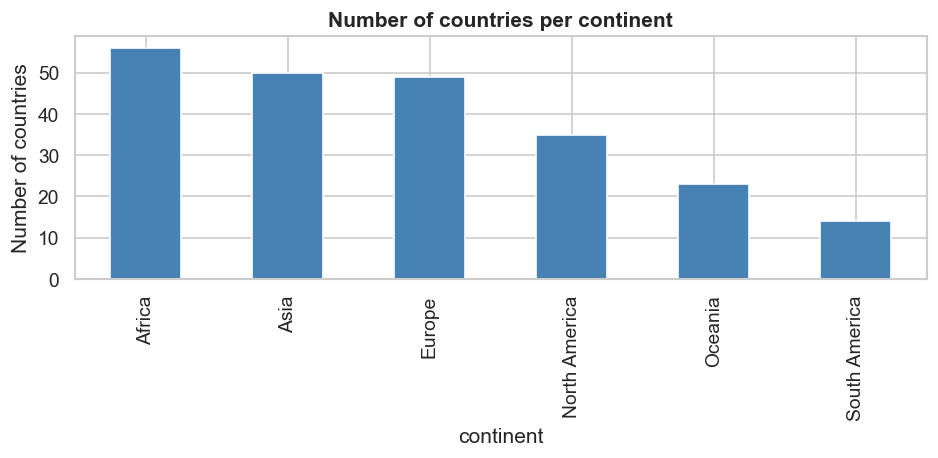

,continent,countries
0,Africa,56
1,Asia,50
2,Europe,49
3,North America,35
4,Oceania,23
5,South America,14


In [ ]:
# Countries per continent 
cont = run_query("""
MATCH (c:Country)-[:IN_CONTINENT]->(k:Continent)
RETURN k.name AS continent, count(c) AS countries ORDER BY countries DESC
""")
ax = cont.set_index("continent")["countries"].plot.bar(color="steelblue", figsize=(8,4))
ax.set_title("Number of countries per continent", fontweight="bold")
ax.set_ylabel("Number of countries"); plt.tight_layout(); plt.show()
cont

The bar chart shows how the countries are distributed among the continents. Africa and Asia are the two most represented continents, while South America has the smallest number of countries. This is important to keep in mind for the next steps: the communities and the centrality results will be partly influenced by how many countries each continent brings into the graph.

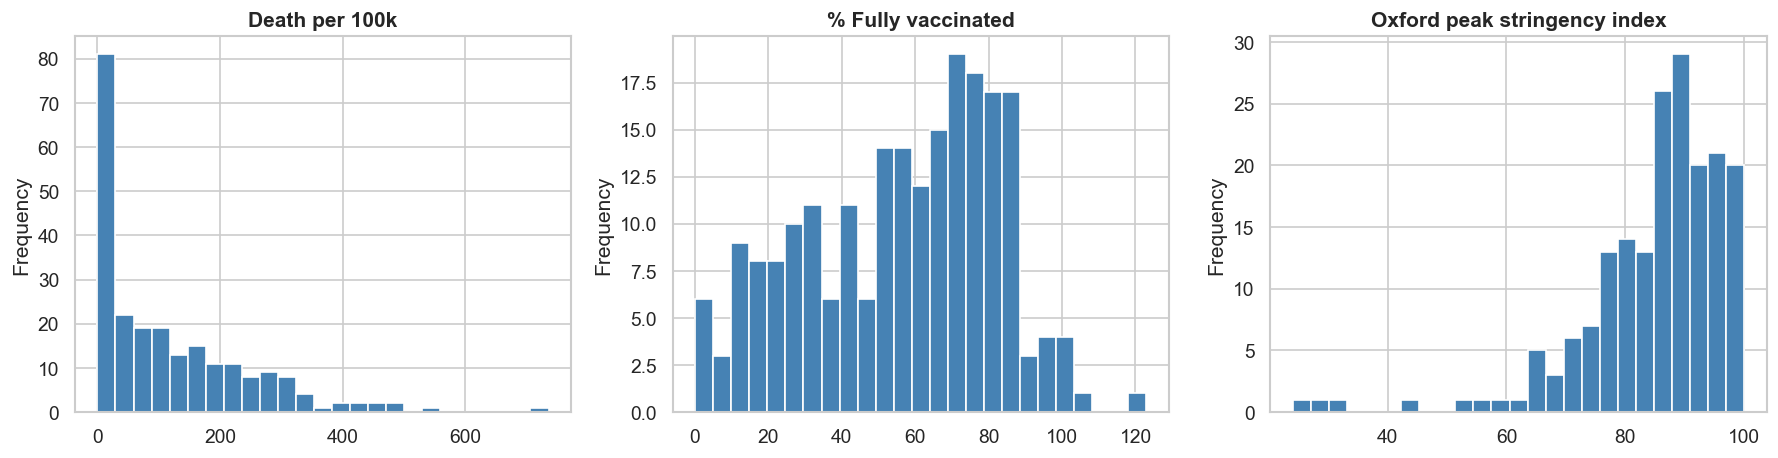

,deaths_100k,vax_pct,stringency
count,231.00,217.00,185.00
mean,117.58,56.16,85.10
std,126.55,26.28,12.57
min,0.00,0.15,24.07
25%,13.40,34.48,80.09
50%,75.31,59.62,87.04
75%,192.26,76.88,93.52
max,735.74,122.94,100.00


In [ ]:
# pandemic outcomes distribution 
metrics = run_query("""
MATCH (c:Country)
RETURN c.name AS country, c.total_deceased_per100k AS deaths_100k,
       c.pct_fully_vaccinated AS vax_pct, c.peak_stringency AS stringency
""")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
        ["deaths_100k", "vax_pct", "stringency"],
        ["Death per 100k", "% Fully vaccinated", "Oxford peak stringency index"]):
    metrics[col].dropna().plot.hist(bins=25, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
metrics.describe().round(2)

The three histograms give a first idea of how different the countries are in terms of pandemic outcome and response. Deaths per 100k and vaccination coverage are quite spread out, which means there is a strong variability between countries: some had very few deaths, others a lot, and the same happens with the share of fully vaccinated people. The peak stringency index, instead, is more concentrated on high values, telling us that almost every country reached a strong level of restrictions at least once during the pandemic.


Oxford Stringency index is calculated on nine metrics: school closures; workplace closures; cancellation of public events; restrictions on public gatherings; closures of public transport; stay-at-home requirements; public information campaigns; restrictions on internal movements; and international travel controls. 
It's build on the above cited metrics and represent the "closure" of the country and decay of public services.

## 5. Similarity Network Construction — **GDS KNN** 

KNN connect every country to the `topK` more similar country in the standardized feature space using cosine similarity. 
This lead to the creation of `(:Country)-[:SIMILAR {score}]->(:Country)`.

**Why KNN?** `features` is a numeric vector, different node by node. KNN is thought to build a property based similarity graph that is useful when the similarity is due to properties, not due to pre existant connections between nodes.

In [ ]:
# Native projection with 'features' 
for name in ["countriesFeat", "simGraph", "simCypher"]:
    if gds.graph.exists(name)["exists"]:
        gds.graph.drop(name)

G_feat, _ = gds.graph.project("countriesFeat",
                              {"Country": {"properties": ["features"]}}, "*")
print("Projection 'countriesFeat':", G_feat.node_count(), "nodi")

Projection 'countriesFeat': 231 nodi


In [ ]:
# Writing SIMILAR relationships on the database
res = gds.knn.write(G_feat, nodeProperties=["features"], topK=5,
                    sampleRate=1.0, randomSeed=42,
                    writeRelationshipType="SIMILAR", writeProperty="score", concurrency=1)
print("SIMILAR raltionships written:", res["relationshipsWritten"])
print("avg similarity:", round(res["similarityDistribution"]["mean"], 3))
display(run_query("""
MATCH (a:Country)-[r:SIMILAR]->(b:Country)
RETURN a.name AS from, b.name AS to, round(r.score,3) AS score
ORDER BY score DESC LIMIT 10
"""))

SIMILAR raltionships written: 1155
avg similarity: 0.903


,from,to,score
0,Pitcairn Islands,Niue,0.996
1,Niue,Pitcairn Islands,0.996
2,Czech Republic,Slovakia,0.994
3,Slovakia,Czech Republic,0.994
4,Guernsey,Jersey,0.992
5,Benin,Togo,0.992
6,Togo,Benin,0.992
7,Jersey,Guernsey,0.992
8,Saint Helena,North Korea,0.988
9,North Korea,Saint Helena,0.988


KNN created 1155 `SIMILAR` relationships with a very high average similarity (~0.90), which is expected since every country is linked to its 5 closest neighbours in the feature space. Looking at the result I managed to achieve I can tell that country ranked as most similar present same details on economic field and result to be really close geographically speaking. This ensure I'm using feature that capture the real similarity and avoid noise allowing to rank as similar countries that effectively are similar.

count    231.00
mean      10.00
std        3.21
min        5.00
25%        7.00
50%       10.00
75%       12.00
max       20.00
Name: degree, dtype: float64


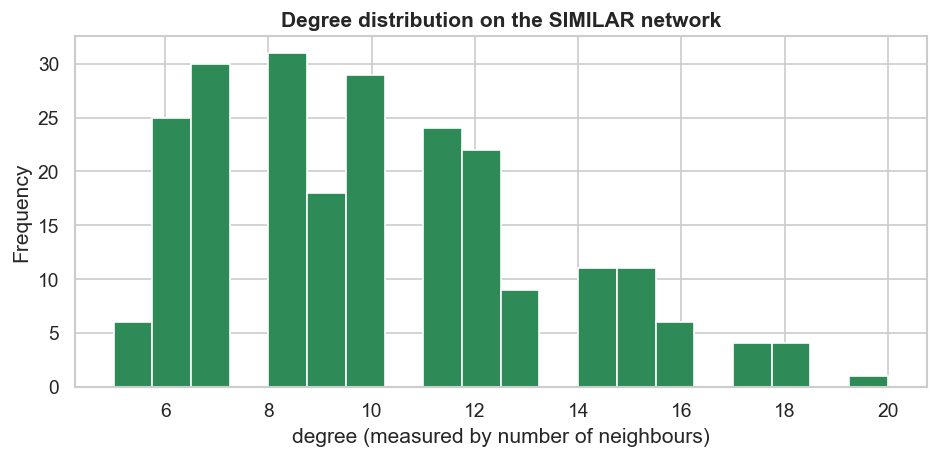

Top 10 more connected countries:


,country,degree
0,Democratic Republic of the Congo,20
1,Switzerland,18
2,France,18
3,Mali,18
4,Mauritania,18
5,New Caledonia,17
6,Portugal,17
7,Sierra Leone,17
8,Chad,17
9,Ghana,16


In [ ]:
# Degree distribution of the SIMILAR network
deg = run_query("""
MATCH (c:Country)-[:SIMILAR]-()
RETURN c.name AS country, count(*) AS degree ORDER BY degree DESC
""")
print(deg["degree"].describe().round(2))
fig, ax = plt.subplots(figsize=(8,4))
deg["degree"].plot.hist(bins=20, color="seagreen", edgecolor="white", ax=ax)
ax.set_title("Degree distribution on the SIMILAR network", fontweight="bold")
ax.set_xlabel("degree (measured by number of neighbours)"); plt.tight_layout(); plt.show()
print("Top 10 more connected countries:"); deg.head(10)

The degree distribution describes how many neighbours each country has in the `SIMILAR` network. Since KNN forces every node to point to its `topK = 5` neighbours, the minimum degree is 5, but many countries have a higher degree because they are also chosen as neighbour by other countries (the relationship is created in both directions). The countries with the highest degree are the ones that act as "typical" profiles: a lot of other countries consider them among their closest matches. 

In [ ]:
# Weakly connected components on the SIMILAR network
if gds.graph.exists("simGraph")["exists"]:
    gds.graph.drop("simGraph")
G_sim, _ = gds.graph.project("simGraph", "Country",
    {"SIMILAR": {"orientation": "UNDIRECTED", "properties": "score"}})
wcc = gds.wcc.stream(G_sim)
print(f"WCC: {wcc['componentId'].nunique()}")
print(wcc["componentId"].value_counts().head())

WCC: 1
componentId
0    231
Name: count, dtype: int64


Since the Weakly Connected Component Analysis returned a single component containing 231 countries (SIMILAR network dimension) I can tell that SIMILAR network is fully connected and there is no isoated group of countries. 


## 6. — RQ1: *Which countries origin communities with similar pandemic profile?*

I will answer my first research question in this way:
- **Projection:** Native (`simGraph`) on `Country` nodes, using `SIMILAR` as relation weighted on `score`.
- **Technique — Louvain :** Grants me to detect high density groups (in term of connections) 
  Useful since I'm searching natural partiton of countries similar toghether bur unsimilar to others.

In [ ]:
# ── 6.1 Louvain on 'simGraph' projection 
gds.louvain.write(G_sim, writeProperty="community", relationshipWeightProperty="score")
comm = run_query("""
MATCH (c:Country)
RETURN c.community AS community, count(*) AS size,
       round(avg(c.total_deceased_per100k),1) AS avg_deaths_100k,
       round(avg(c.pct_fully_vaccinated),1)   AS avg_vax_pct,
       round(avg(c.peak_stringency),1)        AS avg_stringency,
       round(avg(c.gdp_per_capita_usd),0)     AS avg_gdp_pc
ORDER BY size DESC
""")
print("Communities:", comm.shape[0]); comm

Communities: 11


,community,size,avg_deaths_100k,avg_vax_pct,avg_stringency,avg_gdp_pc
0,111,31,147.2,78.8,80.1,65927.0
1,156,31,77.0,57.7,95.4,6673.0
2,212,26,17.2,27.5,84.8,1625.0
3,88,25,304.6,61.8,88.3,9460.0
4,205,24,98.1,72.7,88.0,19386.0
5,133,24,26.5,31.4,85.1,2773.0
6,183,24,210.9,68.7,91.0,20144.0
7,179,15,73.4,33.0,84.0,4571.0
8,182,15,28.1,74.1,81.8,11811.0
9,184,8,266.5,62.6,83.7,23428.0


Louvain found 11 communities of different size. Already from the averages in this table I can see that the groups are not random: the average values of deaths per 100k, vaccination coverage, stringency and GDP per capita change clearly from one community to another. For example the first community has a very high GDP per capita and high vaccination coverage, while the smaller communities at the bottom have much lower GDP and vaccination. So each community seems to describe a different "pandemic profile". I comment the composition of the biggest groups in detail right below.

In [ ]:
# Composition of the top 4 communities 
for cid in comm.head(4)["community"].tolist():
    members = run_query(
        "MATCH (c:Country) WHERE c.community=$cid "
        "RETURN c.name AS country ORDER BY country", {"cid": int(cid)})
    print(f"\n Community {cid} ({len(members)} countries)")
    print(", ".join(members["country"].tolist()))


 Community 111 (31 countries)
Andorra, Australia, Austria, Belgium, Canada, Cayman Islands, Denmark, Faroe Islands, France, Germany, Greenland, Hong Kong, Iceland, Ireland, Isle of Man, Israel, Italy, Liechtenstein, Luxembourg, Macau, Malta, Monaco, Netherlands, New Zealand, Norway, Singapore, Spain, Sweden, Switzerland, United Kingdom, United States of America

 Community 156 (31 countries)
Algeria, Azerbaijan, Bahamas, Bhutan, Cape Verde, China, Cuba, Dominican Republic, El Salvador, Eritrea, Guatemala, Guyana, Honduras, India, Jamaica, Jordan, Kazakhstan, Kuwait, Kyrgyzstan, Laos, Lebanon, Morocco, Myanmar, Nepal, Oman, Palestine, Philippines, Rwanda, Sri Lanka, Suriname, Vietnam

 Community 212 (26 countries)
Cambodia, Central African Republic, Chad, Comoros, Democratic Republic of the Congo, Djibouti, Equatorial Guinea, Ethiopia, Gambia, Guinea, Guinea-Bissau, Haiti, Indonesia, Lesotho, Liberia, Madagascar, Malawi, Mauritania, Republic of the Congo, Senegal, Sierra Leone, Somalia

**RQ1 Answer.** Louvain communities groups countries using complessive pandemic profile.  
Comparing mean per countries for the following statistics (death/100k, vaccination coverage, stringency peak, GDP per capita)
emerge various interpretable clusters. 
I can obsever that: 
1. the first community is composed by "rich" and well developed countries from North America, West Europe and some Islanands.
2. Second community is composed by country from North Africa such as Algeria, Eritrea, Guyana, Morocco and others from and South Asia such as China, Kazakhstanm Sti Lanka etc... It's possible to observe that even some islands in middle America are present.
3. Third community instead is composed by Middle/South Africa mainly.
4. Fourth community is mostly composed by South America countries and Est Europe countries. Some Asian countries are present too such as Taiwan and Iran.

That said, it's possible to note a clear difference between highly developed states, established years ago and having had time to stabilize, and poorer states that have recently emerged from geopolitical conflicts or were created more recently.

The islands, on the other hand, are distributed somewhat among the various communities according to continental territorial influences.

It's clear how the territories of North America and South America reside in the different communities.
Even in Europe, there's a strong division based on the geographic positioning of the states; in fact, we see a clear division between East and West. This is also observed in Africa between North and Central/South, and in Asia between Northeast Asia and Southwest Asia.

## 7. RQ2: *Which countries are the most central/representative in the similarity network?*


- **Cypher Projection:**  Creating a cypher projection keeping only the SIMILAR edges of the net with score above a threshold. Centrality in this case measure a robust representativeness.
- **Techniques:**
  - **PageRank**: A country is central if it is similar to other countries that are also central. Propaget the importance through the weighted edges.
  - **Betweenness**: This allows me to measure how much a country is used as a bridge on the shortest paths. It highlights a structural role other than local popularity.

In [ ]:
# Projecting only on SIMILAR relationships with score >= 0.6 
THRESHOLD = 0.6
if gds.graph.exists("simCypher")["exists"]:
    gds.graph.drop("simCypher")

G_cy, _ = gds.graph.cypher.project(
    """
    MATCH (a:Country)-[r:SIMILAR]-(b:Country)
    WHERE r.score >= $threshold
    RETURN gds.graph.project($graph_name, a, b,
        { relationshipProperties: { score: r.score },
          relationshipType: 'STRONG_SIM' },
        { undirectedRelationshipTypes: ['STRONG_SIM'] })
    """,
    database=NEO4J_DATABASE, threshold=THRESHOLD, graph_name="simCypher")
print("Cypher projection 'simCypher':", G_cy.node_count(), "nodes,",
      G_cy.relationship_count(), "edges (score >=", THRESHOLD, ")")

Cypher projection 'simCypher': 231 nodes, 4620 edges (score >= 0.6 )


In [ ]:
# Applying page rank on previous projection
gds.pageRank.write(G_cy, writeProperty="pagerank",
                   relationshipWeightProperty="score", maxIterations=50)
pr = run_query("""
MATCH (c:Country)
RETURN c.name AS country, c.continent AS continent,
       round(c.pagerank,3) AS pagerank, c.community AS community
ORDER BY pagerank DESC LIMIT 12
""")
print("Top 12 countries retrieved by page rank:"); pr

Top 12 countries retrieved by page rank:


,country,continent,pagerank,community
0,Democratic Republic of the Congo,None,1.829,212
1,Switzerland,None,1.680,111
2,Mauritania,None,1.677,212
3,France,None,1.637,111
4,Mali,None,1.633,133
5,New Caledonia,None,1.616,205
6,Portugal,None,1.609,183
7,Sierra Leone,None,1.591,212
8,Chad,None,1.573,212
9,Tuvalu,None,1.516,205


This table shows the top 12 countries scored in desc order by page rank performed on SIMILAR network. As I expected "Democratic Republic of the Congo" is still the first one even in this analysis. This is happening because this country is the one with the highest degree in the network. 
Since page rank consider important countries that are connected to other countries, I was (correctly) expecting, more or less, the same countries found in the network degree analysis.

In [ ]:
#Same as before but with betweenness
gds.betweenness.write(G_cy, writeProperty="betweenness")
bw = run_query("""
MATCH (c:Country)
RETURN c.name AS country, c.continent AS continent,
       round(c.betweenness,1) AS betweenness
ORDER BY betweenness DESC LIMIT 12
""")
print("Top 12 countries per Betweenness:"); bw

Top 12 countries per Betweenness:


,country,continent,betweenness
0,Fiji,None,1530.0
1,Mauritania,None,1393.7
2,Belarus,None,1303.7
3,Saudi Arabia,None,1296.1
4,Japan,None,1270.2
5,Macedonia,None,1246.9
6,Panama,None,1217.6
7,United States Virgin Islands,None,1177.1
8,Montenegro,None,1113.0
9,Qatar,None,1106.0


Betweenness measures a different kind of centrality: it counts how often a country lies on the shortest paths between other countries. The top list here is almost completely different from the PageRank one (Fiji, Mauritania, Belarus, Saudi Arabia, Japan...). These countries are not necessarily the most typical ones, but they connect groups that would otherwise be far apart.

The fact that betweennes and page rank retrieve two different sets of countries is a clear signal that both are capturing different roles in the graph.

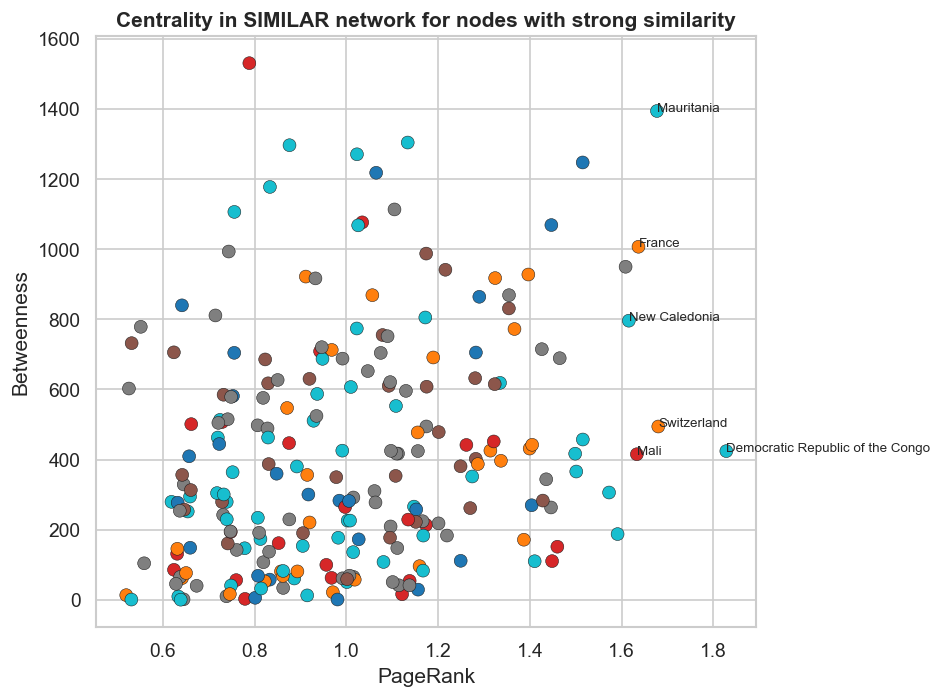

In [ ]:
# Comparing the two measures used
cmp = run_query("""
MATCH (c:Country) WHERE c.pagerank IS NOT NULL
RETURN c.name AS country, c.pagerank AS pagerank,
       c.betweenness AS betweenness, c.community AS community
""")
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(cmp["pagerank"], cmp["betweenness"], c=cmp["community"],
           cmap="tab10", s=60, edgecolor="k", linewidth=.3)
for _, r in cmp.sort_values("pagerank").tail(6).iterrows():
    ax.annotate(r["country"], (r["pagerank"], r["betweenness"]), fontsize=8)
ax.set_xlabel("PageRank"); ax.set_ylabel("Betweenness")
ax.set_title("Centrality in SIMILAR network for nodes with strong similarity", fontweight="bold")
plt.tight_layout(); plt.show()

**RQ2 Answer.** This scatter plot puts together the two centrality measures: PageRank on the x axis, Betweenness on the y axis, and the colour of each point is the Louvain community.

The first thing I notice is that the two measures are **not correlated**: the points are spread all over the plane and there is no clear diagonal line. This means that being a "typical/representative" country (high PageRank) and being a "bridge" between groups (high Betweenness) are two different roles, and a country can have one without the other. So there is not a single answer to "which is the most central country", it depends on what kind of centrality I am interested in.

Reading the plot by regions I can describe three types of countries:
- **High PageRank, low/medium Betweenness** Such as Democratic Republic of the Congo, Switzerland, Mali etc... these are the most central countries for Page Rank and this happens because a lot of different countries point to them, but those countries are not the one that connect communities or groups of country together. 
- **Low/medium PageRank, high Betweenness** Such as the Fiji (that is not plotted but I know that it's fiji's country since the betweennes and page rank values correspond), represent no more the most central country according to Page Rank (so it won't have many connections) but it represents a global bridge between countries in the SIMILAR network. If those type of nodes will be removed, I would have had a more isolated network.
- **High on both axes** Such as Mauritania, represent the most central country over the two metrics in the net. They act as representatitve country in the network and as bridges through communities.

Another analysis that can be performed is looking at the colours to see if all the contries that compose a specific Louvain community shows high centrality.
Analyzing the plot I can thell that this phenomenum is not happening, since in every communities there will be one or two main bridge node, and one or two principal node (using page rank). This shows no evidence of full central communities in the network.

**So, to answer RQ2:** if I look at pure representativeness, the most central countries are the high-PageRank ones such as Democratic Republic of the Congo, Switzerland and *France; if I look at the structural/bridge role, the most central are the high-Betweenness ones such as Fiji, Mauritania and Belarus. The countries that score high on both measures, with Mauritania as the clearest case, are the most central overall, because they combine local importance and a global connecting role.

## 7.5 Verifying indexes usage

I know that an index can be created even if it doesn't make sense. Nothing stops us from doing so. Therefore, to verify its use, it's necessary to profile the query execution by invoking the execution planner, which is the software that translates the declarative query into actual procedural language.

This way, I ensure I'm creating sensible indexes that do not worsen network performance

In [ ]:
#Using profile to test if the execution planned effectively uses the indexes created before.

show_plan("MATCH (c:Country) WHERE c.community = $cid RETURN c.name",
          {"cid": int(comm.iloc[0]["community"])}, profile=True)

show_plan("MATCH (a:Country)-[r:SIMILAR]-(b:Country) WHERE r.score >= $t RETURN count(*)",
          {"t": THRESHOLD}, profile=True)

show_plan("MATCH (a:Country)-[r:SIMILAR]-(b:Country) WHERE r.score >= 0.99 RETURN a.name, b.name",
          profile=True)

• ProduceResults@covid-19  —  `c.name`   [31 rows]
    • Projection@covid-19  —  c.name AS `c.name`   [31 rows]
        • NodeIndexSeek@covid-19  —  RANGE INDEX c:Country(community) WHERE community = $cid   [31 rows]
• ProduceResults@covid-19  —  `count(*)`   [1 rows]
    • EagerAggregation@covid-19  —  count(*) AS `count(*)`   [1 rows]
        • Filter@covid-19  —  (a:Country AND b:Country)   [2310 rows]
            • UndirectedRelationshipIndexSeekByRange@covid-19  —  RANGE INDEX (a)-[:SIMILAR(score)]-(b) WHERE score >= $t   [2310 rows]
• ProduceResults@covid-19  —  `a.name`, `b.name`   [16 rows]
    • Projection@covid-19  —  a.name AS `a.name`, b.name AS `b.name`   [16 rows]
        • Filter@covid-19  —  (a:Country AND b:Country)   [16 rows]
            • UndirectedRelationshipIndexSeekByRange@covid-19  —  RANGE INDEX (a)-[:SIMILAR(score)]-(b) WHERE score >= $autodouble_0   [16 rows]


**Index Usage**: In all the three queries is it possible to notice that Execution Planner is taking advantage of the indexes previously created.
 
This lead to better performance in real life scenarios, allowing Execution Planner to use data structures (such the index itself) to access faster data.

## 8. Network Visualization

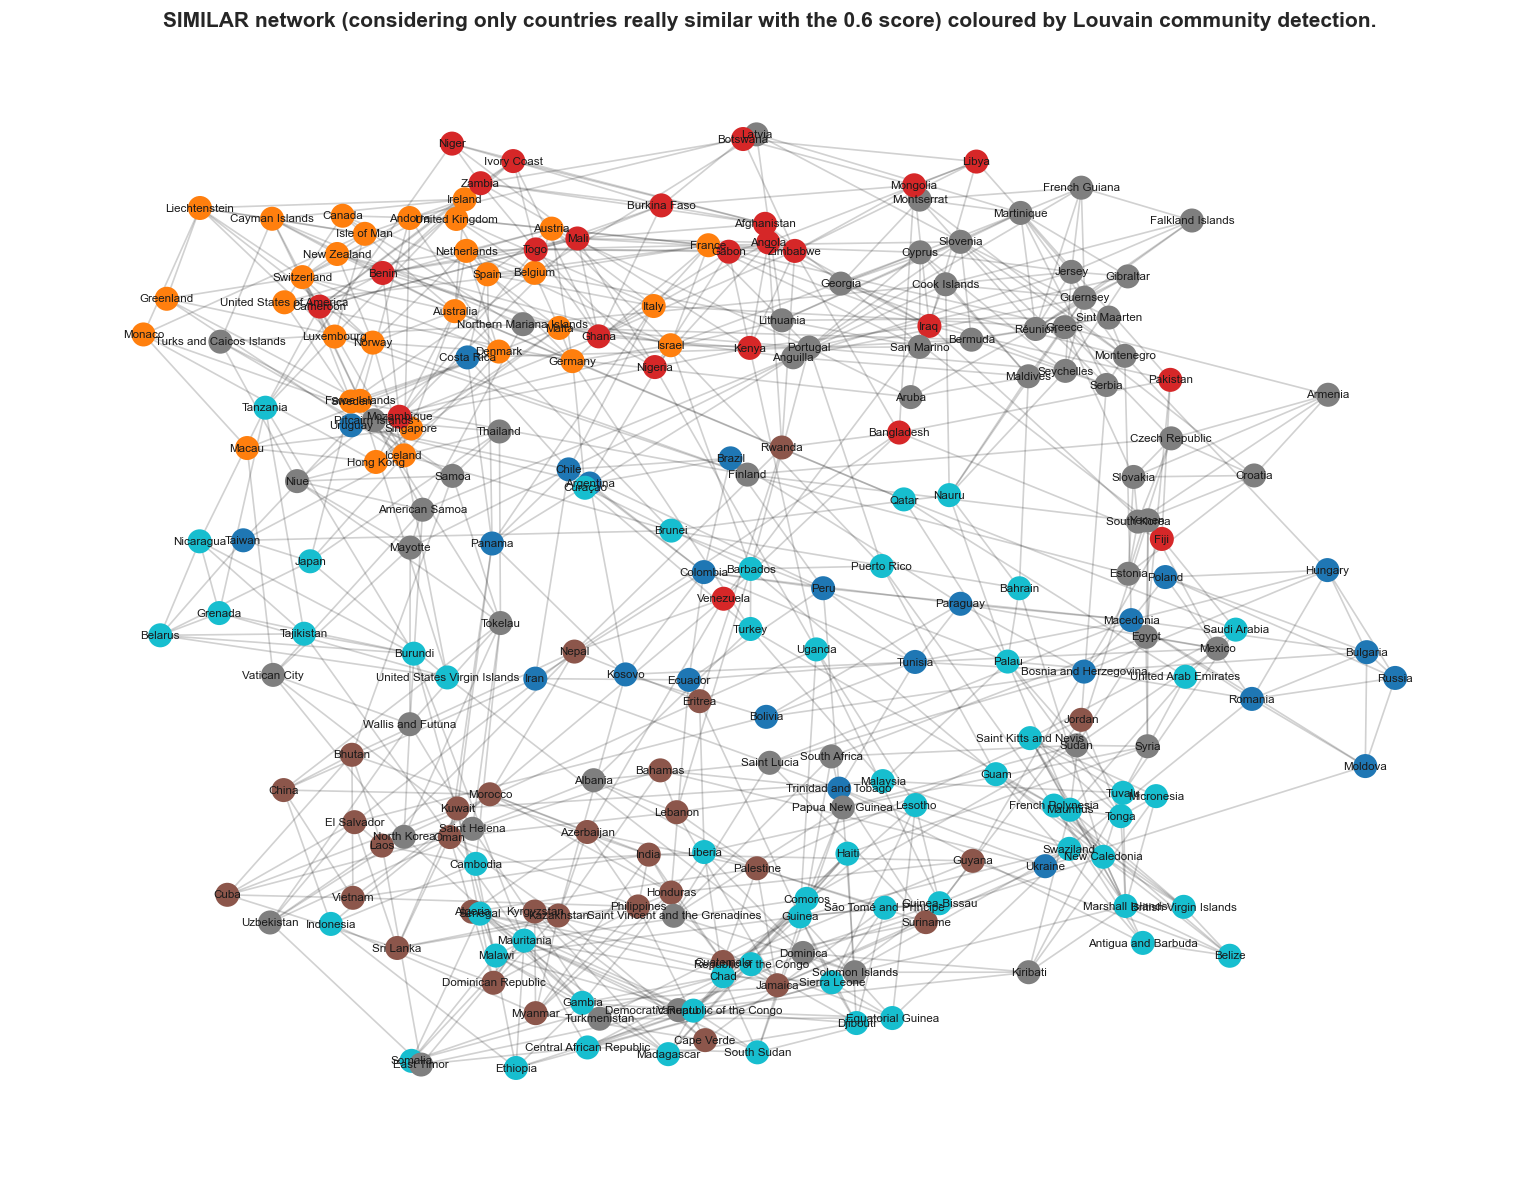

In [ ]:
#SIMILAR network visualization through networkx
edges = run_query("""
MATCH (a:Country)-[r:SIMILAR]->(b:Country) WHERE r.score >= 0.6
RETURN a.name AS src, b.name AS dst, r.score AS w, a.community AS comm
""")
G = nx.Graph()
for _, e in edges.iterrows():
    G.add_edge(e["src"], e["dst"], weight=e["w"])
comm_map = {r["src"]: r["comm"] for _, r in edges.iterrows()}
colors = [comm_map.get(n, 0) for n in G.nodes()]
plt.figure(figsize=(13, 10))
pos = nx.spring_layout(G, seed=42, k=0.35)
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="tab10", node_size=180)
nx.draw_networkx_labels(G, pos, font_size=7)
plt.title("SIMILAR network (considering only countries really similar with the 0.6 score) coloured by Louvain community detection.", fontweight="bold")
plt.axis("off"); plt.tight_layout(); plt.show()

This is a visual summary of all the work done before. Every node is a country, the edges are the strong SIMILAR links and the colour is the Louvain community. 
Using this plot allows me to affirm that nodes that belong to the same community tend to cluster in the space, since they have similar pandemic profile. Clusters are quite well separated, but some nodes can be seen distant from their respective communities since they act as a bridge through communities.

In [ ]:
# Cleanup of the projections made. best practice.
for name in ["countriesFeat", "simGraph", "simCypher"]:
    if gds.graph.exists(name)["exists"]:
        gds.graph.drop(name)
driver.close()
print("Closing connection and cleaning projections.")

Closing connection and cleaning projections.


## Conclusions

I've transformed a tabular dataset from COVID-19 in a data graph using countries and continents with a similarity based on standardized features calling in SIMILAR net.
Once built the SIMILAR network I've answered at the two main research questions using different Graph Analytics algorithms and techiniques.
Then i analized results obrained and cleaned all the projection created.

